<a href="https://colab.research.google.com/github/Almuzhidul/Machine-Learning-from-Scratch/blob/main/CMBO_DNN_LR_Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Library**

In [ ]:
import pandas as pd
import numpy as np
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, activations
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dense, Input
import tensorflow as tf
import math
import random
import torch
import keras
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical
from sklearn.utils import shuffle
from keras.callbacks import ReduceLROnPlateau
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold, cross_val_score

#**Baca Dataset**

In [ ]:
df = pd.read_csv("/content/diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print(df.shape)

(768, 9)


In [ ]:
print(df.Outcome.value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


###**Mengecek Missing Value**

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


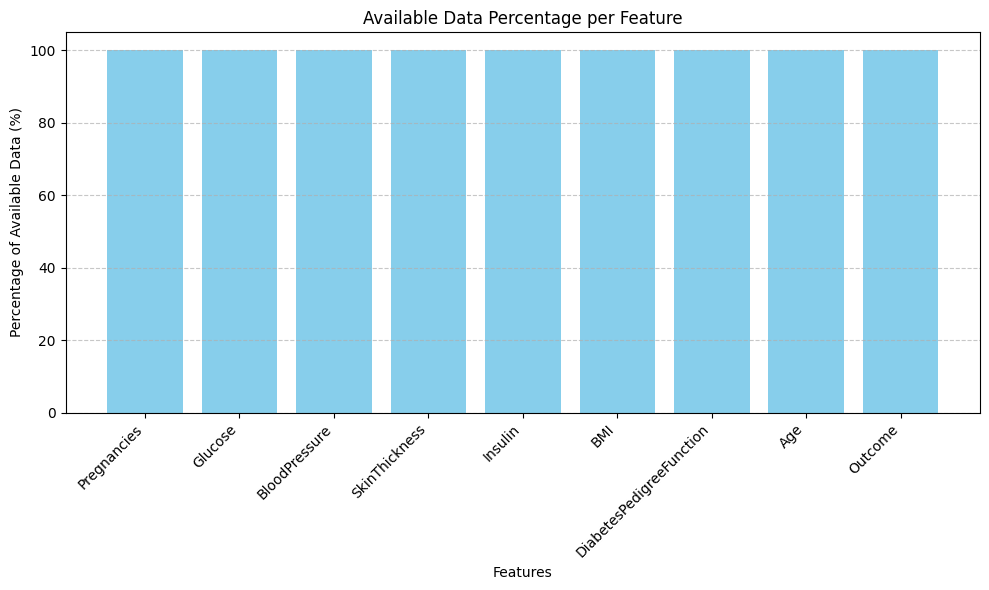

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Menghitung jumlah missing values di setiap fitur
missing_values = df.isnull().sum()

# Menghitung persentase data yang tersedia
available_percentage = ((len(df) - missing_values) / len(df)) * 100

# Membuat bar chart
plt.figure(figsize=(10, 6))
plt.bar(available_percentage.index, available_percentage.values, color='skyblue')

# Menambahkan label dan title
plt.xlabel('Features')
plt.ylabel('Percentage of Available Data (%)')
plt.title('Available Data Percentage per Feature')

# Menyesuaikan tampilan untuk label X agar tidak tumpang tindih
plt.xticks(rotation=45, ha='right')

# Menambahkan grid agar chart lebih mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()  # Agar label tidak terpotong
plt.show()

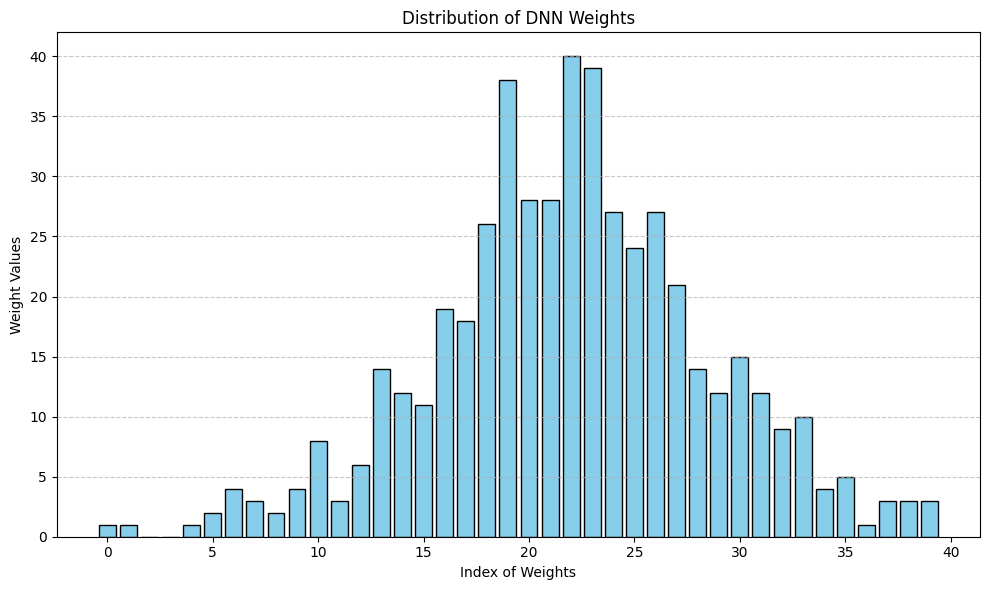

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data: weights of DNN
y_values = np.array([ 1.,  1.,  0.,  0.,  1.,  2.,  4.,  3.,  2.,  4.,  8.,  3.,  6.,
        14., 12., 11., 19., 18., 26., 38., 28., 28., 40., 39., 27., 24.,
        27., 21., 14., 12., 15., 12.,  9., 10.,  4.,  5.,  1.,  3.,  3.,
         3.])

# Create a bar chart for the given y_values (weights of DNN)
plt.figure(figsize=(10, 6))

# Plot the bar chart
plt.bar(range(len(y_values)), y_values, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Index of Weights')
plt.ylabel('Weight Values')
plt.title('Distribution of DNN Weights')

# Show grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.tight_layout()
plt.show()


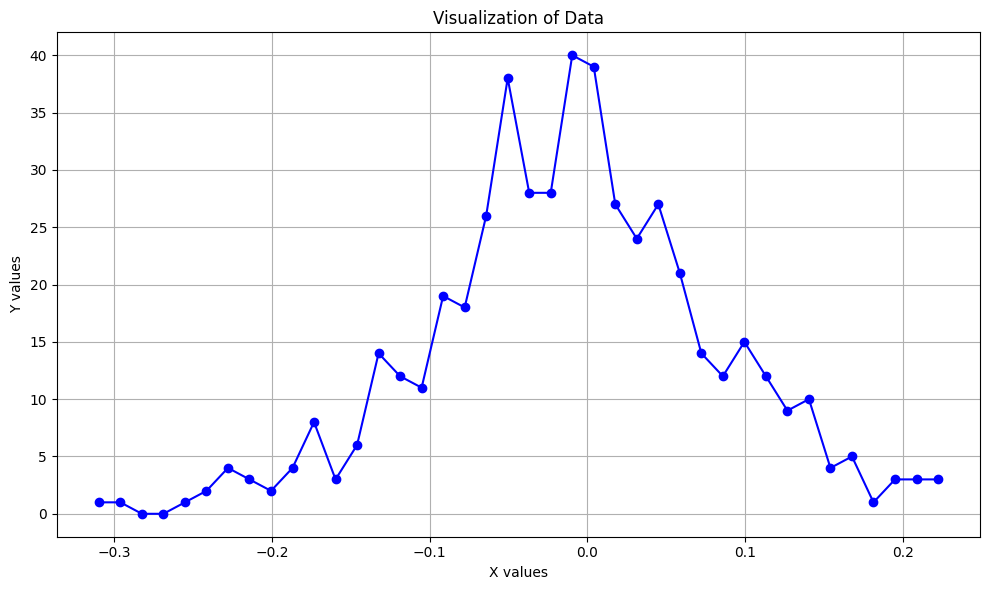

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
y_values = np.array([ 1.,  1.,  0.,  0.,  1.,  2.,  4.,  3.,  2.,  4.,  8.,  3.,  6.,
        14., 12., 11., 19., 18., 26., 38., 28., 28., 40., 39., 27., 24.,
        27., 21., 14., 12., 15., 12.,  9., 10.,  4.,  5.,  1.,  3.,  3.,
         3.])

x_values = np.array([-0.30983087, -0.29618558, -0.28254029, -0.268895  , -0.25524971,
        -0.24160442, -0.22795913, -0.21431383, -0.20066854, -0.18702325,
        -0.17337796, -0.15973267, -0.14608738, -0.13244209, -0.1187968 ,
        -0.10515151, -0.09150622, -0.07786093, -0.06421564, -0.05057035,
        -0.03692506, -0.02327976, -0.00963447,  0.00401082,  0.01765611,
         0.0313014 ,  0.04494669,  0.05859198,  0.07223728,  0.08588257,
         0.09952785,  0.11317314,  0.12681843,  0.14046372,  0.15410902,
         0.16775431,  0.1813996 ,  0.19504489,  0.20869018,  0.22233547,
         0.23598076])

# Menyesuaikan panjang array
if len(x_values) > len(y_values):
    x_values = x_values[:len(y_values)]
elif len(x_values) < len(y_values):
    y_values = y_values[:len(x_values)]

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, marker='o', color='b', linestyle='-', markersize=6)

# Add labels and title
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Visualization of Data')

# Show grid
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
pip install dataprep

ERROR: Operation cancelled by user


In [ ]:
from dataprep.eda.missing import plot_missing
plot_missing(df)

ModuleNotFoundError: No module named 'dataprep'

In [ ]:
import missingno as msno

<Axes: >

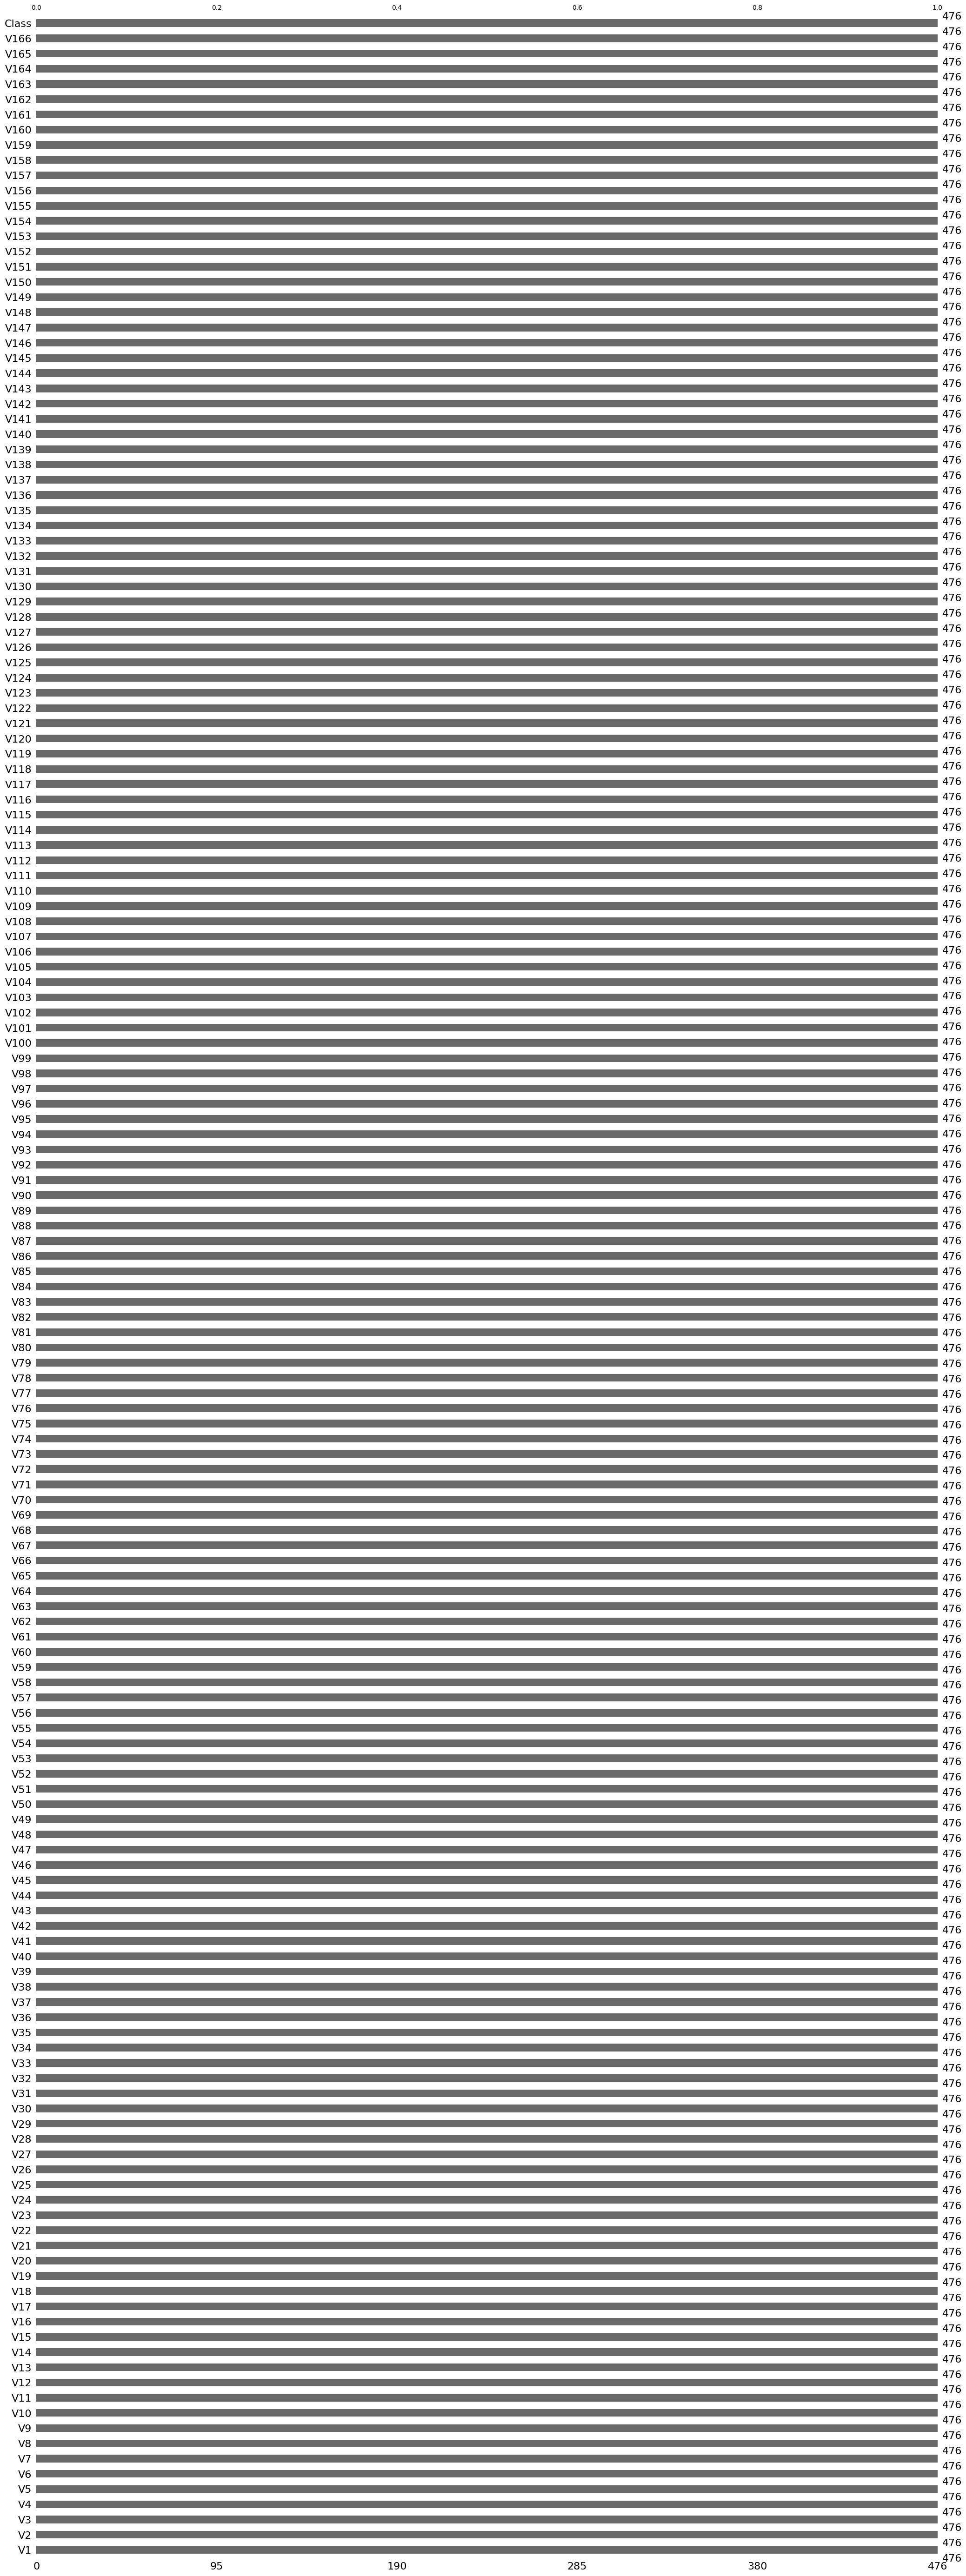

In [ ]:
msno.bar(df)

<Axes: >

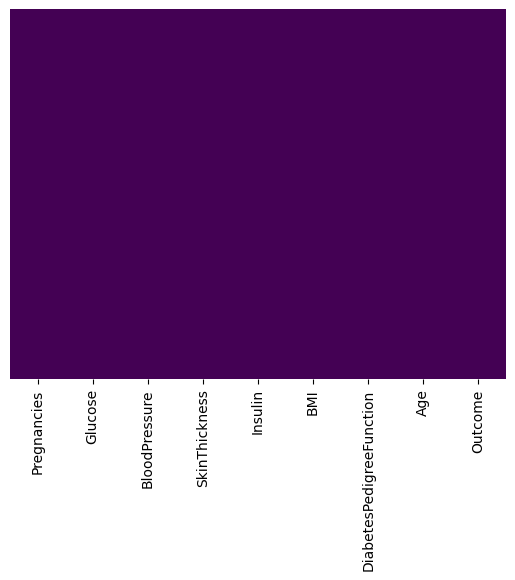

In [ ]:
sns.heatmap(df.isnull(),cbar=False,yticklabels=False,cmap = 'viridis')

###**Mengecek Outlier**

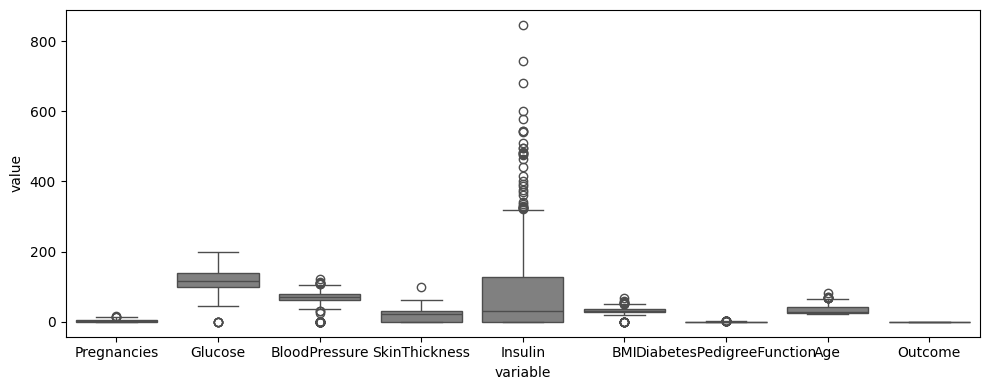

In [ ]:
df1=df.select_dtypes(include=['float64', 'int64'])#Memilih kolom numerik
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x="variable", y="value", color='grey',orient='v', data=pd.melt(df1))
plt.tight_layout()

In [ ]:
#Menghitung Skor IQR
sorted(df)

Q1=df.quantile(0.25)
Q3=df.quantile(0.75)
IQR=Q3-Q1
print(IQR)

Pregnancies                   5.0000
Glucose                      41.2500
BloodPressure                18.0000
SkinThickness                32.0000
Insulin                     127.2500
BMI                           9.3000
DiabetesPedigreeFunction      0.3825
Age                          17.0000
Outcome                       1.0000
dtype: float64


In [ ]:
#Menghapus Outlier
df_clear = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
df_clear

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
5,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


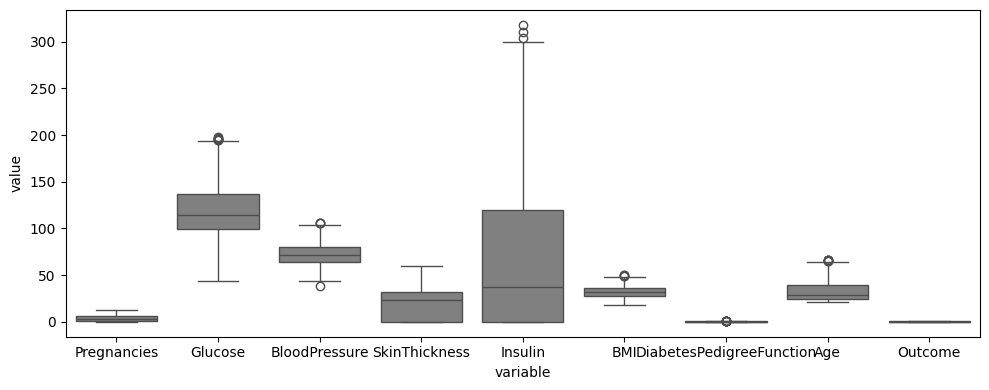

In [ ]:
df1=df_clear.select_dtypes(include=['float64', 'int64'])#Memilih kolom numerik
fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(x="variable", y="value", color='grey',orient='v', data=pd.melt(df1))
plt.tight_layout()

In [ ]:
def find_outliers_IQR(df):

   q1=df.quantile(0.25)

   q3=df.quantile(0.75)

   IQR=q3-q1

   outliers = df[((df<(q1-1.5*IQR)) | (df>(q3+1.5*IQR)))]

   return outliers

In [ ]:
# outliers = find_outliers_IQR(df['Age'])

# print("number of outliers: "+ str(len(outliers)))

# print("max outlier value: "+ str(outliers.max()))

# print("min outlier value: "+ str(outliers.min()))

# outliers

In [ ]:
feature_df = df.columns
for i in feature_df:
  outliers = find_outliers_IQR(df[i])
  print("number of outliers feature "+ str(i) + " : " + str(len(outliers)))

number of outliers feature Pregnancies : 4
number of outliers feature Glucose : 5
number of outliers feature BloodPressure : 45
number of outliers feature SkinThickness : 1
number of outliers feature Insulin : 34
number of outliers feature BMI : 19
number of outliers feature DiabetesPedigreeFunction : 29
number of outliers feature Age : 9
number of outliers feature Outcome : 0


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
nan_features = [features for features in df.columns if df[features].isnull().sum()>=1]
print(nan_features)
print(len(nan_features))

[]
0


In [ ]:
num_features = [features for features in df.columns if df[features].dtype!='O']

print(num_features)
print(len(num_features))

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
9


In [ ]:
discrete_features = [features for features in num_features if len(df[features].unique())<10]
print(len(discrete_features))
print(discrete_features)

1
['Outcome']


In [ ]:
continous_features = [features for features in num_features if features not in discrete_features]
print(len(continous_features))
print(continous_features)

8
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


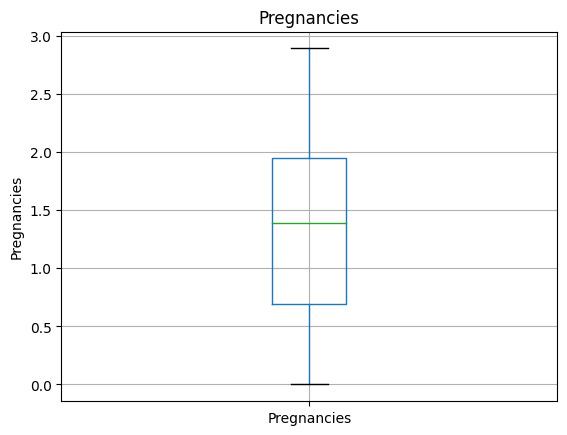

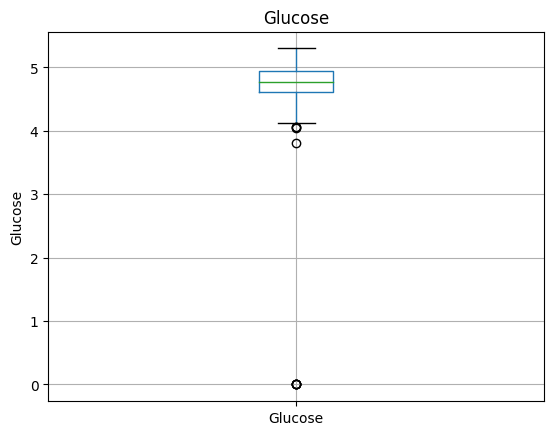

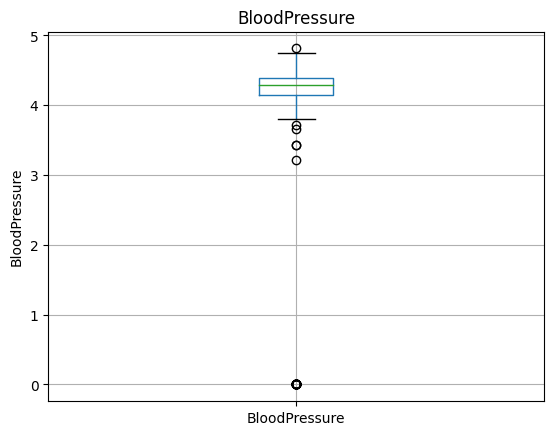

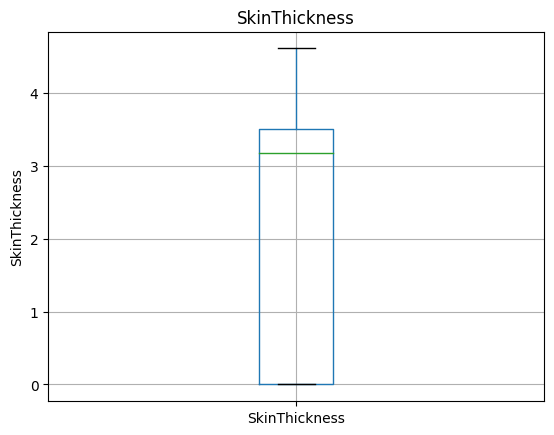

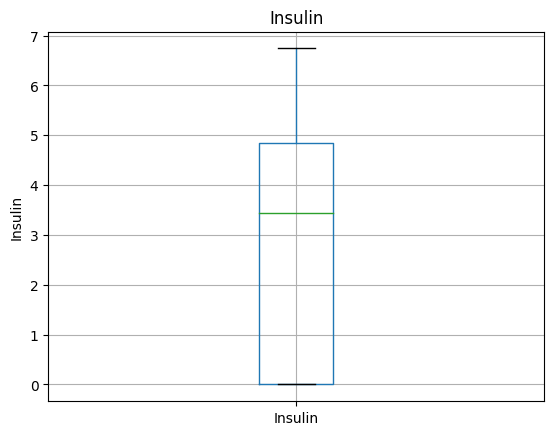

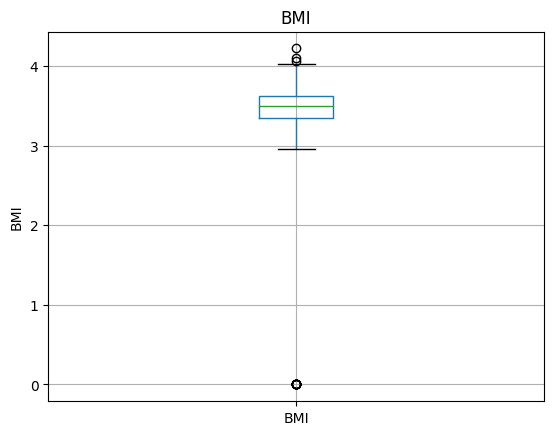

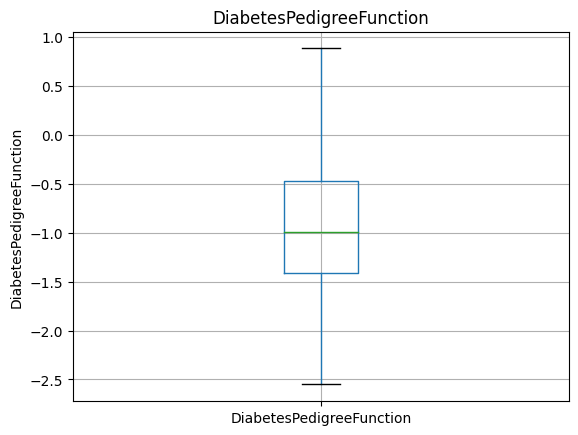

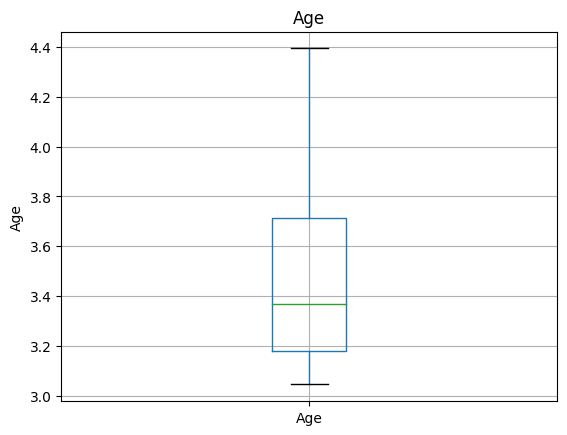

In [ ]:
for features in continous_features:
    data = df.copy()

    if 0 in data[features].unique():
        data[features] = np.log1p(data[features])
        data.boxplot(column=features)
        plt.ylabel(features)
        plt.title(features)
        plt.show()
    else:
        data[features] = np.log(data[features])
        data.boxplot(column=features)
        plt.ylabel(features)
        plt.title(features)
        plt.show()

In [ ]:
categorical_features = [features for features in df.columns if df[features].dtype=='O' ]
print(categorical_features)
print(len(categorical_features))

[]
0


In [ ]:
for features in continous_features:
    if 0 in df[features].unique():
        df[features] = np.log1p(df[features])
    else:
        df[features] = np.log(df[features])

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,-0.466809,3.912023,1
1,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,-1.046969,3.433987,0
2,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,-0.397497,3.465736,1
3,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,-1.789761,3.044522,0
4,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,0.827678,3.496508,1
...,...,...,...,...,...,...,...,...,...
763,2.397895,4.624973,4.343805,3.891820,5.198497,3.523415,-1.766092,4.143135,0
764,1.098612,4.812184,4.262680,3.332205,0.000000,3.632309,-1.078810,3.295837,0
765,1.791759,4.804021,4.290459,3.178054,4.727388,3.303217,-1.406497,3.401197,0
766,0.693147,4.844187,4.110874,0.000000,0.000000,3.437208,-1.052683,3.850148,1


In [ ]:
feature_df = df.columns
for i in feature_df:
  outliers = find_outliers_IQR(df[i])
  print("number of outliers feature "+ str(i) + " : " + str(len(outliers)))

number of outliers feature Pregnancies : 0
number of outliers feature Glucose : 9
number of outliers feature BloodPressure : 41
number of outliers feature SkinThickness : 0
number of outliers feature Insulin : 0
number of outliers feature BMI : 14
number of outliers feature DiabetesPedigreeFunction : 0
number of outliers feature Age : 0
number of outliers feature Outcome : 0


In [ ]:
# upper_limit = df['BMI'].quantile(0.99)
# lower_limit = df['BMI'].quantile(0.01)

# df = df[(df.BMI < upper_limit) & (df.BMI > lower_limit)]

In [ ]:
# upper_limit = df['BloodPressure'].quantile(0.99)
# lower_limit = df['BloodPressure'].quantile(0.01)

# df = df[(df.BloodPressure < upper_limit) & (df.BloodPressure > lower_limit)]

In [ ]:
feature_df = df.columns
for i in feature_df:
  outliers = find_outliers_IQR(df[i])
  print("number of outliers feature "+ str(i) + " : " + str(len(outliers)))

number of outliers feature Pregnancies : 0
number of outliers feature Glucose : 9
number of outliers feature BloodPressure : 41
number of outliers feature SkinThickness : 0
number of outliers feature Insulin : 0
number of outliers feature BMI : 14
number of outliers feature DiabetesPedigreeFunction : 0
number of outliers feature Age : 0
number of outliers feature Outcome : 0


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,1.945910,5.003946,4.290459,3.583519,0.000000,3.543854,-0.466809,3.912023,1
1,0.693147,4.454347,4.204693,3.401197,0.000000,3.317816,-1.046969,3.433987,0
2,2.197225,5.214936,4.174387,0.000000,0.000000,3.190476,-0.397497,3.465736,1
3,0.693147,4.499810,4.204693,3.178054,4.553877,3.370738,-1.789761,3.044522,0
4,0.000000,4.927254,3.713572,3.583519,5.129899,3.786460,0.827678,3.496508,1
...,...,...,...,...,...,...,...,...,...
763,2.397895,4.624973,4.343805,3.891820,5.198497,3.523415,-1.766092,4.143135,0
764,1.098612,4.812184,4.262680,3.332205,0.000000,3.632309,-1.078810,3.295837,0
765,1.791759,4.804021,4.290459,3.178054,4.727388,3.303217,-1.406497,3.401197,0
766,0.693147,4.844187,4.110874,0.000000,0.000000,3.437208,-1.052683,3.850148,1


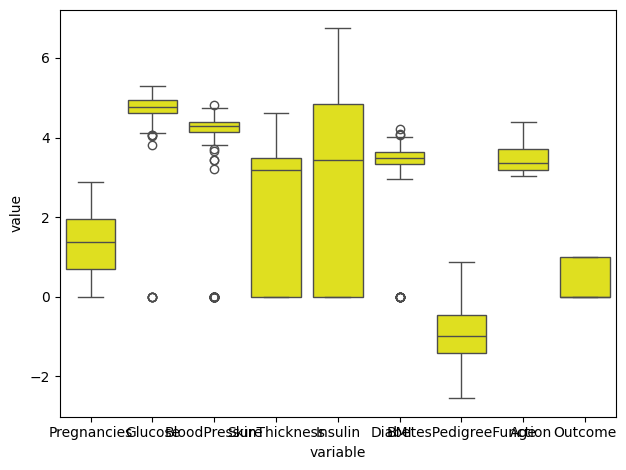

In [ ]:
df1=df.select_dtypes(include=['float64', 'int64'])#Memilih kolom numerik

sns.boxplot(x="variable", y="value", color='yellow',orient='v', data=pd.melt(df1))
plt.tight_layout()

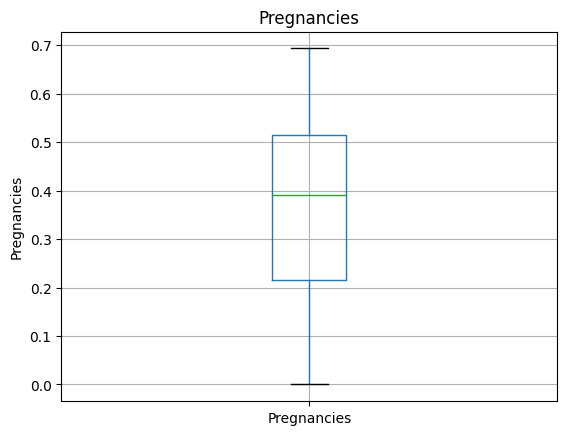

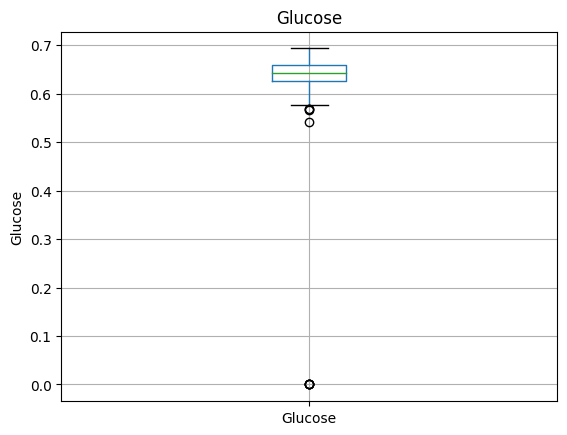

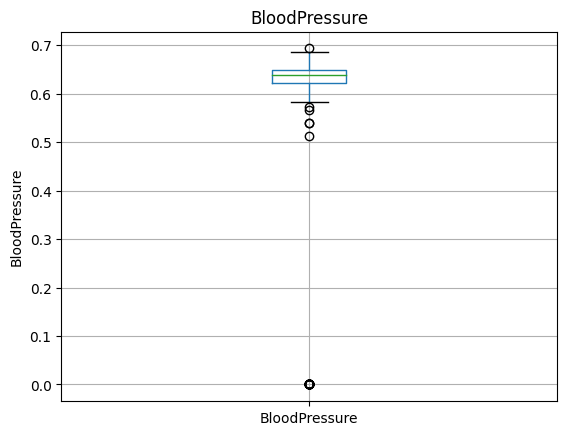

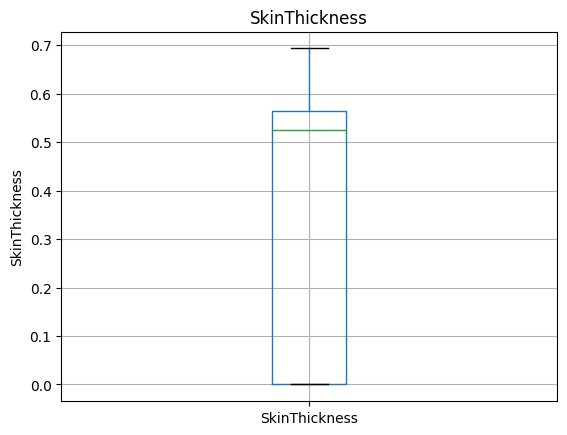

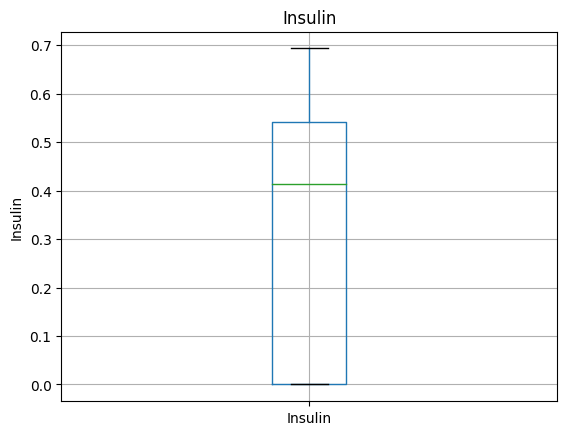

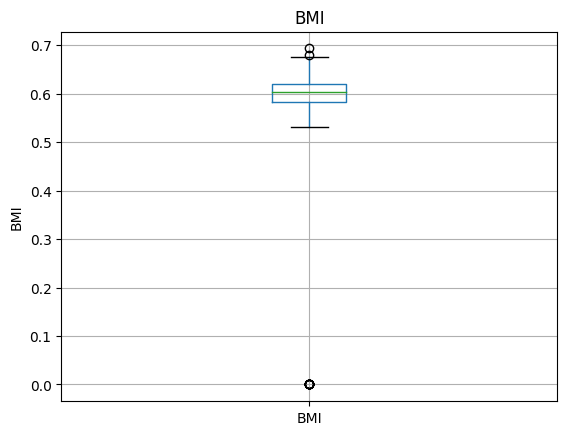

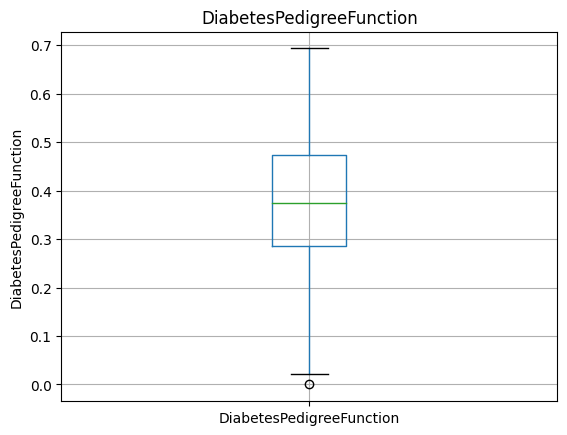

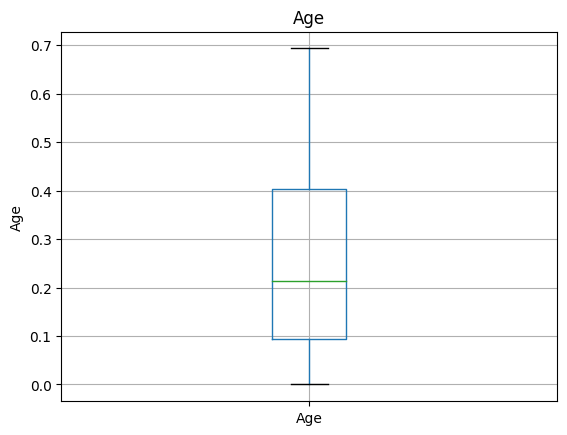

In [ ]:
for features in continous_features:
    data = data.copy()

    if 0 in data[features].unique():
        data[features] = np.log1p(data[features])
        data.boxplot(column=features)
        plt.ylabel(features)
        plt.title(features)
        plt.show()
    else:
        data[features] = np.log(data[features])
        data.boxplot(column=features)
        plt.ylabel(features)
        plt.title(features)
        plt.show()

In [ ]:
# #Menghitung Skor IQR
# sorted(df)

# Q1=df.quantile(0.25)
# Q3=df.quantile(0.75)
# IQR=Q3-Q1
# print(IQR)

In [ ]:
# #Menghapus Outlier
# df_clear = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)]
# df_clear

In [ ]:
# #Melihat Outlier
# sns.boxplot(x="variable", y="value", color='green',orient='v', data=pd.melt(df_clear))

# plt.show()

In [ ]:
# # Min-Max Normalization
# df = df_clear.drop('Class', axis=1)
# df_norm = (df-df.min())/(df.max()-df.min())
# df_norm = pd.concat((df_norm, df_clear.Outcome), 1)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

feature_scale = [features for features in df.columns if features not in ['Outcome']]
scalar = MinMaxScaler()
scalar.fit_transform(df[feature_scale])
print(len(feature_scale))

8


In [ ]:
data = pd.concat([df[['Outcome']].reset_index(drop=True),
                    pd.DataFrame(scalar.transform(df[feature_scale]), columns=feature_scale)],
                    axis=1)

In [ ]:
data

,Outcome,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1,0.352941,0.743719,0.590164,0.353535,0.000000,0.500745,0.234415,0.483333
1,0,0.058824,0.427136,0.540984,0.292929,0.000000,0.396423,0.116567,0.166667
2,1,0.470588,0.919598,0.524590,0.000000,0.000000,0.347243,0.253629,0.183333
3,0,0.058824,0.447236,0.540984,0.232323,0.111111,0.418778,0.038002,0.000000
4,1,0.000000,0.688442,0.327869,0.353535,0.198582,0.642325,0.943638,0.200000
...,...,...,...,...,...,...,...,...,...
763,0,0.588235,0.507538,0.622951,0.484848,0.212766,0.490313,0.039710,0.700000
764,0,0.117647,0.613065,0.573770,0.272727,0.000000,0.548435,0.111870,0.100000
765,0,0.294118,0.608040,0.590164,0.232323,0.132388,0.390462,0.071307,0.150000
766,1,0.058824,0.633166,0.491803,0.000000,0.000000,0.448584,0.115713,0.433333


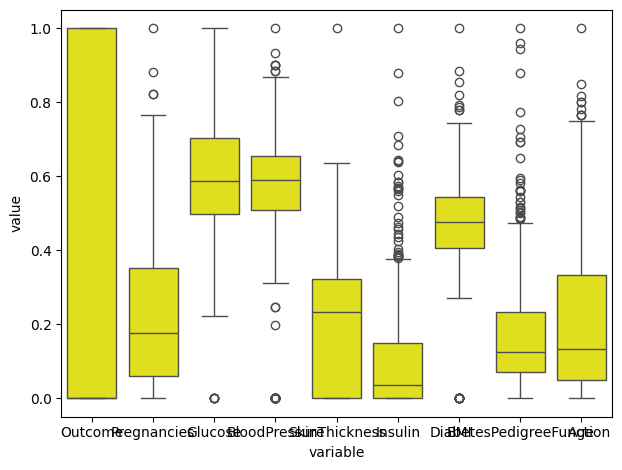

In [ ]:
df1=data.select_dtypes(include=['float64', 'int64'])#Memilih kolom numerik

sns.boxplot(x="variable", y="value", color='yellow',orient='v', data=pd.melt(df1))
plt.tight_layout()

###**Pisahkan variabel independen dan dependen**

In [ ]:
# df = shuffle(data)
df = shuffle(df)
X = df.drop(['Outcome'], axis = 1)
X = np.array(X)
Y = np.array(df['Outcome'])

###**Label Encoding**

In [ ]:
l_encode = LabelEncoder()
l_encode.fit(Y)
Y = l_encode.transform(Y)
Y = to_categorical(Y)
Y

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]], dtype=float32)

###**Split Data**

In [ ]:
print("----------------------------")
print("Kelas Data")
print("----------------------------")
print(df.Class.value_counts())

----------------------------
Kelas Data
----------------------------
0    269
1    207
Name: Class, dtype: int64


In [ ]:
train_x, test_x, train_y, test_y = train_test_split(X,Y, test_size = 0.3, stratify=Y)
train_x.shape, train_y.shape, test_x.shape, test_y.shape

((537, 8), (537, 2), (231, 8), (231, 2))

#**Create Topology DNN**

In [ ]:
def neural_net(layer_sizes):
    model = Sequential()
    model.add(layers.InputLayer(input_shape=(layer_sizes[0],)))
    for width in layer_sizes[1:-1]:
      model.add(layers.Dense(
              width, activation=tf.nn.relu))
    model.add(layers.Dense(
              layer_sizes[-1], activation=tf.nn.softmax))
    return model

In [ ]:
input_size = X.shape[1]
output_size = train_y.shape[1]
# layer_size = [input_size, int(2/3*input_size), int(2/3*input_size), int(2/3*input_size), output_size]
layer_size = [input_size, int(3*input_size), int(3*input_size), int(3*input_size), output_size]
u_model = neural_net(layer_size)
u_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 24)                216       
                                                                 
 dense_1 (Dense)             (None, 24)                600       
                                                                 
 dense_2 (Dense)             (None, 24)                600       
                                                                 
 dense_3 (Dense)             (None, 2)                 50        
                                                                 
Total params: 1,466
Trainable params: 1,466
Non-trainable params: 0
_________________________________________________________________


In [ ]:
s = u_model.trainable_variables[0][0]
s2 = u_model.trainable_variables[0][-1]

(array([1., 0., 1., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 2., 0., 2., 1.,
        0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.,
        2., 2., 0., 0., 3., 2.]),
 array([-0.41535184, -0.39504871, -0.37474558, -0.35444245, -0.33413932,
        -0.31383619, -0.29353306, -0.27322993, -0.2529268 , -0.23262367,
        -0.21232054, -0.19201741, -0.17171428, -0.15141115, -0.13110802,
        -0.11080489, -0.09050176, -0.07019863, -0.0498955 , -0.02959237,
        -0.00928923,  0.0110139 ,  0.03131703,  0.05162016,  0.07192329,
         0.09222642,  0.11252955,  0.13283268,  0.15313581,  0.17343894,
         0.19374207,  0.2140452 ,  0.23434833,  0.25465146,  0.27495459,
         0.29525772,  0.31556085,  0.33586398,  0.35616711,  0.37647024,
         0.39677337]),
 <BarContainer object of 40 artists>)

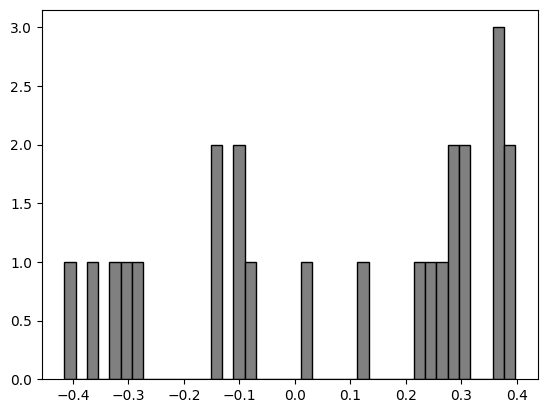

In [ ]:
plt.hist(s, edgecolor='black', bins=40, color='grey')

(array([10.,  8.,  9., 13.,  5., 16., 16., 10., 10., 15., 14.,  7., 17.,
         7., 12., 16., 17., 14., 10., 21.,  4., 17., 15., 12.,  9.,  9.,
         9., 16.,  9., 11., 17., 17., 10., 11.,  7., 20., 14., 13.,  9.,
        22.]),
 array([-0.09444848, -0.089714  , -0.08497951, -0.08024502, -0.07551053,
        -0.07077605, -0.06604156, -0.06130707, -0.05657258, -0.0518381 ,
        -0.04710361, -0.04236912, -0.03763463, -0.03290014, -0.02816566,
        -0.02343117, -0.01869668, -0.01396219, -0.00922771, -0.00449322,
         0.00024127,  0.00497576,  0.00971024,  0.01444473,  0.01917922,
         0.02391371,  0.02864819,  0.03338268,  0.03811717,  0.04285166,
         0.04758614,  0.05232063,  0.05705512,  0.06178961,  0.0665241 ,
         0.07125858,  0.07599307,  0.08072755,  0.08546205,  0.09019653,
         0.09493102]),
 <BarContainer object of 40 artists>)

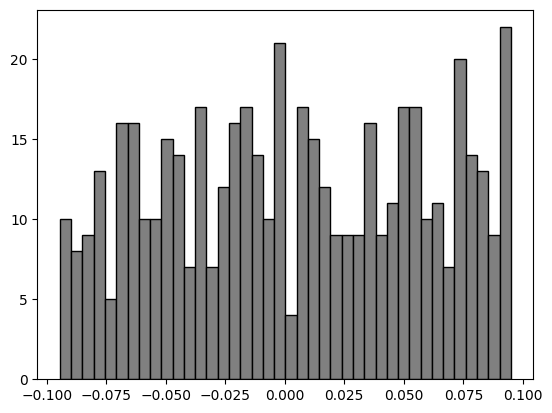

In [ ]:
plt.hist(s2, edgecolor='black', bins=40, color='grey')

In [ ]:
num_classes=2
u_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
# reduce_lr = ReduceLROnPlateau(monitor='val_loss',
#                                      factor=0.01,
#                                      patience=10,
#                                      min_lr=0.0001,
#                                      cooldown=0)
history = u_model.fit(train_x, train_y,
                      batch_size=3,
                      epochs=100,
                      verbose=1)
y_val_pred_probs = u_model.predict(test_x, verbose=0)
thresholds = [0.5] * num_classes  # You can adjust these thresholds based on your requirements
y_val_pred_binary = np.zeros_like(y_val_pred_probs, dtype=int)
for i in range(num_classes):
  y_val_pred_binary[:, i] = (y_val_pred_probs[:, i] > thresholds[i]).astype(int)
y_val_pred_labels = l_encode.inverse_transform(np.argmax(y_val_pred_binary, axis=1))
y_true = l_encode.inverse_transform(np.argmax(test_y, axis=1))
scores = u_model.evaluate(train_x, train_y, verbose=0)
print("Loss Train: ", scores[0])
print("AKurasi Train: ", scores[1])
print("Akurasi Test : ", accuracy_score(y_true, y_val_pred_labels))
print("Precision Test : ", precision_score(y_true, y_val_pred_labels,average="macro"))
print("Recall Test : ", recall_score(y_true, y_val_pred_labels,average="macro"))
print("F1-Score Test : ", f1_score(y_true, y_val_pred_labels,average="macro"))

Epoch 1/100
111/111 [==============================] - 5s 23ms/step - loss: 4.0315 - accuracy: 0.7387
Epoch 2/100
111/111 [==============================] - 2s 19ms/step - loss: 1.6920 - accuracy: 0.8198
Epoch 3/100
111/111 [==============================] - 2s 19ms/step - loss: 1.0164 - accuracy: 0.8739
Epoch 4/100
111/111 [==============================] - 1s 10ms/step - loss: 0.4071 - accuracy: 0.8979
Epoch 5/100
111/111 [==============================] - 1s 10ms/step - loss: 0.3347 - accuracy: 0.9069
Epoch 6/100
111/111 [==============================] - 1s 9ms/step - loss: 0.1778 - accuracy: 0.9580
Epoch 7/100
111/111 [==============================] - 1s 9ms/step - loss: 0.0801 - accuracy: 0.9700
Epoch 8/100
111/111 [==============================] - 1s 9ms/step - loss: 0.2993 - accuracy: 0.9520
Epoch 9/100
111/111 [==============================] - 1s 13ms/step - loss: 0.1959 - accuracy: 0.9520
Epoch 10/100
111/111 [==============================] - 2s 15ms/step - loss: 0.2457 -

In [ ]:
      inputs=X
      targets=Y
      # Definisikan K-fold Cross Validator
      kfold = KFold(n_splits=5, shuffle=True)
      # Evaluasi model K-fold Cross Validation
      train_acc_per_fold = []
      train_loss_per_fold = []
      test_acc_per_fold = []
      test_loss_per_fold = []
      num_classes=2
      fold_no = 1
      for train, test in kfold.split(inputs, targets):
        u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                      factor=0.01,
                                      patience=10,
                                      min_lr=0.0001,
                                      cooldown=0)
        history = u_model.fit(inputs[train], targets[train],
                              batch_size=4,
                              epochs=100,
                              verbose=1)

Epoch 1/100
114/114 [==============================] - 1s 2ms/step - loss: 0.1434 - accuracy: 0.9385
Epoch 2/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1842 - accuracy: 0.9341
Epoch 3/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1373 - accuracy: 0.9473
Epoch 4/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1600 - accuracy: 0.9363
Epoch 5/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1513 - accuracy: 0.9297
Epoch 6/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1540 - accuracy: 0.9319
Epoch 7/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1541 - accuracy: 0.9385
Epoch 8/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1656 - accuracy: 0.9363
Epoch 9/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1683 - accuracy: 0.9473
Epoch 10/100
114/114 [==============================] - 0s 2ms/step - loss: 0.1691 - accura

In [ ]:
scores = u_model.evaluate(test_x, test_y, verbose=0)
scores

[0.8143301010131836, 0.677570104598999]

In [ ]:
u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = u_model.fit(train_x, train_y, epochs=250, batch_size=3)

#**Determine Population Size**

In [ ]:
initializer = tf.keras.initializers.GlorotUniform()
initializer1 = tf.keras.initializers.GlorotNormal()
pap = []
for i in range(len(layer_size)-1):
  wei = initializer(shape=(layer_size[i], layer_size[i+1]))
  wei = tf.reshape(wei, [layer_size[i]*layer_size[i+1]])
  pap.append(wei)
  bobot = initializer(shape=(layer_size[i+1],))
  pap.append(bobot)

/usr/local/lib/python3.10/dist-packages/keras/initializers/initializers.py:120: UserWarning: The initializer GlorotUniform is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initalizer instance more than once.
  warnings.warn(


In [ ]:
pap

[<tf.Tensor: shape=(82668,), dtype=float32, numpy=
 array([ 0.07470866, -0.07341897, -0.08092582, ...,  0.00302051,
        -0.06431851, -0.00436646], dtype=float32)>,
 <tf.Tensor: shape=(498,), dtype=float32, numpy=
 array([ 6.09993637e-02, -5.99463433e-02, -6.60756528e-02, -6.61458075e-03,
         7.20042586e-02, -6.24135956e-02,  2.96992064e-02, -3.86382267e-02,
        -2.00877786e-02, -6.92929327e-02, -6.44595474e-02, -3.26407701e-03,
         7.19684213e-02, -6.43960610e-02, -7.10374936e-02,  6.29567504e-02,
        -4.77618650e-02,  6.95358068e-02,  6.43367171e-02, -1.55244581e-02,
         9.46927816e-03,  4.73376960e-02, -5.03695533e-02, -5.17871939e-02,
        -5.55899069e-02,  4.57102135e-02,  2.71048397e-03,  5.23610711e-02,
         6.42043352e-03,  5.13535291e-02, -2.48366632e-02,  2.35733911e-02,
         2.13692933e-02, -3.61625701e-02, -2.15446092e-02, -6.26293123e-02,
         3.73902917e-02, -2.18770131e-02, -1.30920112e-02, -5.21420613e-02,
        -2.45603286e-02

In [ ]:
c = tf.concat([pap[0], pap[1], pap[2], pap[3], pap[4], pap[5], pap[6], pap[7]], axis=0)
c

<tf.Tensor: shape=(581168,), dtype=float32, numpy=
array([ 0.07470866, -0.07341897, -0.08092582, ..., -0.02423193,
        0.96255386, -0.9459374 ], dtype=float32)>

#**Create Population**

In [ ]:
def population(num_pop,layer_sizes):
  all_pop = list()
  for i in range(num_pop):
    initializer = tf.keras.initializers.GlorotUniform()
    pap = list()
    for j in range(len(layer_sizes)-1):
      wei = initializer(shape=(layer_sizes[j], layer_sizes[j+1]))
      wei = tf.reshape(wei, [layer_sizes[j]*layer_sizes[j+1]])
      pap.append(wei)
      bobot = initializer(shape=(layer_sizes[j+1],))
      pap.append(bobot)
    c = tf.concat([pap[0], pap[1], pap[2], pap[3], pap[4], pap[5], pap[6], pap[7]], axis=0)
    all_pop.append(c)
  return all_pop

In [ ]:
populasi = population(4,layer_size)
populasi

[<tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([ 0.04207194, -0.03702055,  0.02820399, ..., -0.07613476,
         0.54205894, -0.4769764 ], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([-0.03963315,  0.04933126,  0.04315938, ...,  0.10663027,
        -0.5106375 ,  0.635589  ], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([-0.06995736,  0.0296525 ,  0.06764399, ...,  0.06329072,
        -0.9013376 ,  0.38204575], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([-0.06144544, -0.02313245,  0.05174583, ...,  0.01854438,
        -0.79166925, -0.2980408 ], dtype=float32)>]

#**Assign Parameter to DNN**

In [ ]:
def parameter_w(layer_sizes):
  sizes_w = list()
  for i in range(len(layer_sizes)):
    if i==len(layer_sizes)-1:
      break
    sizes_w.append(layer_sizes[i] * layer_sizes[i+1])
  return sizes_w

In [ ]:
def parameter_b(layer_sizes):
  sizes_b = layer_sizes[1::]
  return sizes_b

In [ ]:
def set_weights(model, w, sizes_w, sizes_b):
  for i, layer in enumerate(model.layers[0:]):
    start_weights = sum(sizes_w[:i]) + sum(sizes_b[:i])
    end_weights = sum(sizes_w[:i+1]) + sum(sizes_b[:i])
    weights = w[start_weights:end_weights]
    w_div = int(sizes_w[i] / sizes_b[i])
    weights = tf.reshape(weights, [w_div, sizes_b[i]])
    biases = w[end_weights:end_weights + sizes_b[i]]
    weights_biases = [weights, biases]
    layer.set_weights(weights_biases)

In [ ]:
size_w = parameter_w(layer_size)
print(size_w)
size_b = parameter_b(layer_size)
print(size_b)

[82668, 248004, 248004, 996]
[498, 498, 498, 2]


In [ ]:
set_weights(u_model, populasi[0], size_w, size_b)

(array([21., 12.,  9., 15.,  6., 11.,  7., 21.,  9., 10., 13., 16., 17.,
        11., 13., 11., 15., 13., 16., 17., 14.,  9., 13., 12., 10.,  8.,
        10., 11., 11., 13.,  8., 12., 13.,  7., 10., 11., 21., 12., 15.,
        15.]),
 array([-9.48925540e-02, -9.01466310e-02, -8.54007080e-02, -8.06547925e-02,
        -7.59088695e-02, -7.11629465e-02, -6.64170235e-02, -6.16711043e-02,
        -5.69251850e-02, -5.21792620e-02, -4.74333391e-02, -4.26874198e-02,
        -3.79414968e-02, -3.31955776e-02, -2.84496564e-02, -2.37037353e-02,
        -1.89578123e-02, -1.42118922e-02, -9.46597010e-03, -4.72004898e-03,
         2.58721411e-05,  4.77179326e-03,  9.51771438e-03,  1.42636364e-02,
         1.90095566e-02,  2.37554796e-02,  2.85014007e-02,  3.32473218e-02,
         3.79932411e-02,  4.27391641e-02,  4.74850833e-02,  5.22310063e-02,
         5.69769293e-02,  6.17228486e-02,  6.64687678e-02,  7.12146908e-02,
         7.59606138e-02,  8.07065368e-02,  8.54524523e-02,  9.01983753e-02,
      

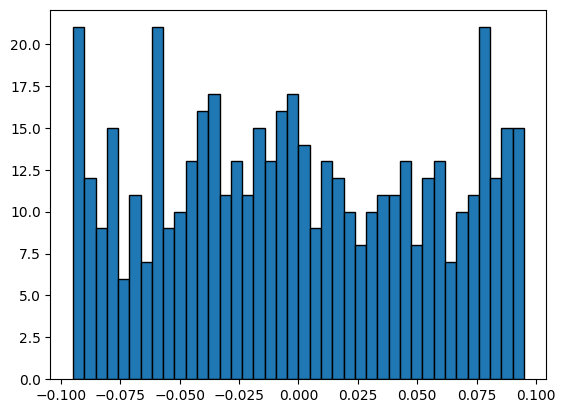

In [ ]:
cmb = u_model.trainable_variables[0][-1]
plt.hist(cmb, edgecolor='black', bins=40)

(array([  4.,   5.,  11.,  21., 249.,  55.,  47.,  40.,  32.,  14.,   8.,
          6.,   3.,   1.,   1.,   0.,   0.,   0.,   0.,   1.]),
 array([-0.0672844 , -0.04217486, -0.01706532,  0.00804423,  0.03315376,
         0.05826331,  0.08337285,  0.10848239,  0.13359194,  0.15870146,
         0.18381101,  0.20892055,  0.2340301 ,  0.25913963,  0.28424919,
         0.30935872,  0.33446825,  0.3595778 ,  0.38468733,  0.40979689,
         0.43490642]),
 <BarContainer object of 20 artists>)

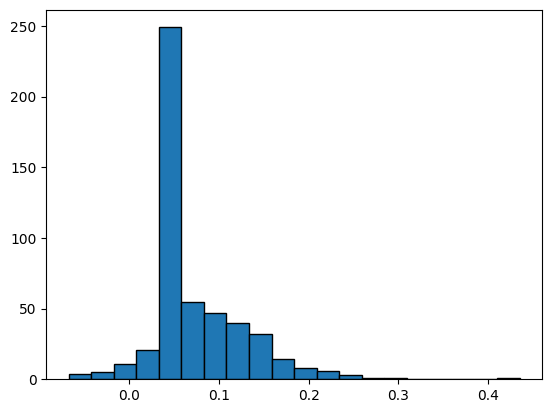

In [ ]:
cmb = u_model.trainable_variables[0][-1]
plt.hist(cmb, edgecolor='black', bins=20)

#**Fungsi Objektif**

In [ ]:
def loss(X, label, con, layer_sizes, sizes_b, sizes_w):
    all_loss = []
    all_acc = []
    for i in con:
      set_weights(u_model, i, sizes_w, sizes_b)
      u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
      reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                     factor=0.01,
                                     patience=10,
                                     min_lr=0.0001,
                                     cooldown=0)
      history = u_model.fit(X, label,
                          batch_size=5,
                          epochs=10,
                          verbose=0)
      scores = u_model.evaluate(X, label, verbose=0)
      all_loss.append(scores[0])
      all_acc.append(scores[1])
    return np.array(all_loss), np.array(all_acc)

In [ ]:
def loss_fold(X, label, con, layer_sizes, sizes_b, sizes_w):
    train_mean_all_loss = []
    train_mean_all_acc = []
    test_mean_all_loss = []
    test_mean_all_acc = []
    for i in con:
      inputs=X
      targets=label
      # Definisikan K-fold Cross Validator
      kfold = KFold(n_splits=5, shuffle=True)
      # Evaluasi model K-fold Cross Validation
      train_acc_per_fold = []
      train_loss_per_fold = []
      test_acc_per_fold = []
      test_loss_per_fold = []
      num_classes=4
      fold_no = 1
      set_weights(u_model, i, sizes_w, sizes_b)
      for train, test in kfold.split(inputs, targets):
        u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                      factor=0.01,
                                      patience=10,
                                      min_lr=0.0001,
                                      cooldown=0)
        history = u_model.fit(inputs[train], targets[train],
                              batch_size=5,
                              epochs=250,
                              verbose=0)
        # Buat skor hasil dari model
        scores_train = u_model.evaluate(inputs[train], targets[train], verbose=0)
        train_loss_per_fold.append(scores_train[0])
        train_acc_per_fold.append(scores_train[1])
        # y_val_pred_probs = u_model.predict(inputs.iloc[test], verbose=0)
        # thresholds = [0.5] * num_classes  # You can adjust these thresholds based on your requirements
        # y_val_pred_binary = np.zeros_like(y_val_pred_probs, dtype=int)
        # for i in range(num_classes):
        #   y_val_pred_binary[:, i] = (y_val_pred_probs[:, i] > thresholds[i]).astype(int)
        # y_val_pred_labels = l_encode.inverse_transform(np.argmax(y_val_pred_binary, axis=1))
        # y_true = l_encode.inverse_transform(np.argmax(targets[test], axis=1))
        # conf_matrix = confusion_matrix(y_true, y_val_pred_labels)
        # plt.figure(figsize=(8, 6))
        # sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=l_encode.classes_, yticklabels=l_encode.classes_)
        # plt.title('Confusion Matrix')
        # plt.xlabel('Predicted Labels')
        # plt.ylabel('True Labels')
        # plt.show()
        # print("Kelas Asli : ", y_true)
        # print("Kelas Prediksi : ", y_val_pred_labels)
        # print("Akurasi : ", accuracy_score(y_true, y_val_pred_labels))
        # print("Precision : ", precision_score(y_true, y_val_pred_labels,average="macro"))
        # print("Recall : ", recall_score(y_true, y_val_pred_labels,average="macro"))
        # print("F1-Score : ", f1_score(y_true, y_val_pred_labels,average="macro"))
        scores_test = u_model.evaluate(inputs[test], targets[test], verbose=0)
        # print(f'Score for fold {fold_no}: {u_model.metrics_names[0]} of {scores[0]}; {u_model.metrics_names[1]} of {scores[1]*100}%')
        test_acc_per_fold.append(scores_test[1])
        test_loss_per_fold.append(scores_test[0])

        # Tambah fold di setiap iterasi
        fold_no = fold_no + 1
      train_mean_all_loss.append(np.mean(train_acc_per_fold))
      train_mean_all_acc.append(np.mean(train_loss_per_fold))
      test_mean_all_loss.append(np.mean(test_loss_per_fold))
      test_mean_all_acc.append(np.mean(test_acc_per_fold))
    return np.array(train_mean_all_loss), np.array(train_mean_all_acc), np.array(test_mean_all_loss), np.array(test_mean_all_acc)

#**CMBO**

###**Determine Cat and Mouse Population**

In [ ]:
def bagi_pop(num_pop, agent):
    num_mouse = math.ceil(num_pop/2)
    num_cat = math.floor(num_pop/2)
    cat_pop = agent[num_mouse::]
    mice_pop = agent[0:num_mouse]
    #pergerakan cat
    random_index = random.randrange(num_mouse)
    I = np.round(1+np.random.rand(num_cat, size_pop))
    r = np.random.rand()
    new_pop = cat_pop+r*(mice_pop[0][random_index] - I * cat_pop)
    return new_pop, cat_pop, mice_pop

In [ ]:
import scipy.stats as stats

def using_indexed_assignment(x):
    "https://stackoverflow.com/a/5284703/190597 (Sven Marnach)"
    result = np.empty(len(x), dtype=int)
    temp = x.argsort()
    result[temp] = np.arange(len(x))
    return result

###**Update Cat**

In [ ]:
# def new_cat(bobot_lama, bobot_baru, loss_lama, loss_baru):
#     hasil = list()
#     bobot_lama = np.array(bobot_lama)
#     bobot_baru = np.array(bobot_baru)
#     loss_lama = np.array(loss_lama)
#     loss_baru = np.array(loss_baru)
#     for i in range(len(loss_baru)):
#       if loss_lama[i] <= loss_baru[i]:
#         hasil.append(bobot_lama[i])
#       else:
#         hasil.append(bobot_baru[i])
#     hasil = tf.convert_to_tensor(hasil)
#     return hasil

In [ ]:
def new_cat(bobot_lama, bobot_baru, loss_lama, loss_baru):
    hasil = list()
    bobot_semua = np.concatenate((bobot_lama, bobot_baru), axis=0)
    all_loss = np.concatenate((loss_lama, loss_baru))
    sort_all_loss = np.argsort(all_loss)
    bobot_sort = np.array(bobot_semua)
    sort_all_bobot = bobot_sort[~sort_all_loss]
    hasil = tf.convert_to_tensor(sort_all_bobot)
    return hasil[0:len(loss_lama)]

###**Create Heaven**

In [ ]:
def update_mice_escape(mice_pop, heaven_pop, mice_loss, heaven_loss):
    I = np.round(1 + np.random.randn(len(mice_pop), size_pop))
    r = np.random.randn()
    new_pop = mice_pop + r * (heaven_pop - I * mice_pop) * np.sign(mice_loss - heaven_loss)[:, np.newaxis]
    return new_pop

#**Hybrid CMBO-DNN**

In [ ]:
num_pop = 4
iterasi = 4
parameter_terbaik = []
banyak_iterasi = []
loss_terbaik = []
accuracy_terbaik = []
all_pop = population(num_pop,layer_size)
u_model = neural_net(layer_size)

In [ ]:
all_pop

[<tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([ 0.07368484, -0.08833115,  0.0733819 , ...,  0.07300354,
         0.9493629 , -1.1380674 ], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([-0.08284791, -0.02661327, -0.04069552, ..., -0.03717262,
        -1.0674207 , -0.34288794], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([ 0.02172574,  0.01436299, -0.05475416, ..., -0.0615845 ,
         0.27991652,  0.18505418], dtype=float32)>,
 <tf.Tensor: shape=(581168,), dtype=float32, numpy=
 array([-0.09228002,  0.02121506, -0.00451693, ..., -0.09873669,
        -1.1889449 ,  0.2733369 ], dtype=float32)>]

In [ ]:
Loss = loss(X, Y, all_pop, layer_size, size_b, size_w)[0]
Loss

array([0.3794952 , 0.32502478, 0.35807514, 0.35948572])

In [ ]:
Loss_test = loss_fold(X, Y, all_pop, layer_size, size_b, size_w)
Loss_test

In [ ]:
Loss

array([0.3794952 , 0.32502478, 0.35807514, 0.35948572])

In [ ]:
# loss(train_x, train_y, all_pop, layer_size, size_b, size_w)[1]

In [ ]:
sorted_loss=using_indexed_assignment(Loss)
sorted_loss

array([3, 0, 1, 2])

In [ ]:
all_pop_sort = np.array(all_pop)
all_pop_sort

array([[ 0.258485  ,  0.2716649 ,  0.38014582, ..., -0.1728572 ,
         0.73110604,  0.76838446],
       [-0.14757901,  0.22629955,  0.18663278, ..., -0.39582986,
        -0.4174165 ,  0.64007175],
       [-0.38585314,  0.4304792 ,  0.32651135, ...,  0.18390179,
        -1.0913576 ,  1.2175792 ],
       [ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.6866175 , -0.6813077 ]], dtype=float32)

In [ ]:
sorted_indices = np.argsort(sorted_loss)
agent = all_pop_sort[sorted_indices]
agent

array([[-0.14757901,  0.22629955,  0.18663278, ..., -0.39582986,
        -0.4174165 ,  0.64007175],
       [-0.38585314,  0.4304792 ,  0.32651135, ...,  0.18390179,
        -1.0913576 ,  1.2175792 ],
       [ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.6866175 , -0.6813077 ],
       [ 0.258485  ,  0.2716649 ,  0.38014582, ..., -0.1728572 ,
         0.73110604,  0.76838446]], dtype=float32)

In [ ]:
# import numpy as geek
# agent = all_pop_sort[~sorted_loss]
# # agent = np.take(all_pop_sort, sorted_loss)
# agent

In [ ]:
size_pop = size_w + size_b
size_pop = sum(size_w+size_b)

In [ ]:
new_pop_cat = bagi_pop(num_pop, agent)
new_pop_cat = tf.convert_to_tensor(new_pop_cat)
new_pop_cat

<tf.Tensor: shape=(3, 2, 1250), dtype=float64, numpy=
array([[[ 0.23326445,  0.16750433,  0.12389259, ...,  0.37063646,
          0.02510435,  0.23512412],
        [ 0.09083623,  0.08881269,  0.29141255, ...,  0.05736277,
          0.01827395,  0.01255053]],

       [[ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
          0.68661749, -0.68130767],
        [ 0.25848499,  0.27166489,  0.38014582, ..., -0.1728572 ,
          0.73110604,  0.76838446]],

       [[-0.14757901,  0.22629955,  0.18663278, ..., -0.39582986,
         -0.41741651,  0.64007175],
        [-0.38585314,  0.4304792 ,  0.32651135, ...,  0.18390179,
         -1.09135759,  1.21757925]]])>

In [ ]:
new_pop_cat[0]

<tf.Tensor: shape=(2, 1250), dtype=float64, numpy=
array([[0.23326445, 0.16750433, 0.12389259, ..., 0.37063646, 0.02510435,
        0.23512412],
       [0.09083623, 0.08881269, 0.29141255, ..., 0.05736277, 0.01827395,
        0.01255053]])>

In [ ]:
new_Loss = loss(train_x, train_y,new_pop_cat[0], layer_size, size_b, size_w)[0]
new_Loss

array([0.40909874, 0.36359358])

In [ ]:
new_Loss = loss_fold(X, Y, new_pop_cat[0], layer_size, size_b, size_w)[2]
new_Loss

NameError: ignored

In [ ]:
Loss_sorted = np.sort(Loss)
Loss_sorted

array([0.32502478, 0.35807514, 0.35948572, 0.3794952 ])

In [ ]:
    bobot_semua = np.concatenate((bobot_lama, bobot_baru), axis=0)
    all_loss = loss_lama + loss_baru
    sort_all_loss = np.argsort(all_loss)
    bobot_sort = np.array(bobot_semua)
    sort_all_bobot = bobot_sort[sort_all_loss]
    hasil = tf.convert_to_tensor(sort_all_bobot)

In [ ]:
bobot_semua = np.concatenate((new_pop_cat[1], new_pop_cat[0]), axis=0)
bobot_semua

array([[ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.68661749, -0.68130767],
       [ 0.25848499,  0.27166489,  0.38014582, ..., -0.1728572 ,
         0.73110604,  0.76838446],
       [ 0.23326445,  0.16750433,  0.12389259, ...,  0.37063646,
         0.02510435,  0.23512412],
       [ 0.09083623,  0.08881269,  0.29141255, ...,  0.05736277,
         0.01827395,  0.01255053]])

In [ ]:
ll_loss =   np.concatenate((Loss_sorted[len(new_pop_cat[1])::], new_Loss), axis=0)
ll_loss

array([0.35948572, 0.3794952 , 0.40909874, 0.36359358])

In [ ]:
sort_all_loss = np.argsort(ll_loss,axis=0)
sort_all_loss

array([0, 3, 1, 2])

In [ ]:
bobot_sort = np.array(bobot_semua)
bobot_sort

array([[ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.68661749, -0.68130767],
       [ 0.25848499,  0.27166489,  0.38014582, ..., -0.1728572 ,
         0.73110604,  0.76838446],
       [ 0.23326445,  0.16750433,  0.12389259, ...,  0.37063646,
         0.02510435,  0.23512412],
       [ 0.09083623,  0.08881269,  0.29141255, ...,  0.05736277,
         0.01827395,  0.01255053]])

In [ ]:
sort_all_bobot = bobot_sort[sort_all_loss]
sort_all_bobot

array([[ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.68661749, -0.68130767],
       [ 0.09083623,  0.08881269,  0.29141255, ...,  0.05736277,
         0.01827395,  0.01255053],
       [ 0.25848499,  0.27166489,  0.38014582, ..., -0.1728572 ,
         0.73110604,  0.76838446],
       [ 0.23326445,  0.16750433,  0.12389259, ...,  0.37063646,
         0.02510435,  0.23512412]])

In [ ]:
selected_cat = new_cat(new_pop_cat[1], new_pop_cat[0], Loss_sorted[len(new_pop_cat[1])::], new_Loss)
selected_cat

<tf.Tensor: shape=(2, 1250), dtype=float64, numpy=
array([[ 0.24275592, -0.24087863,  0.04317847, ...,  0.56733274,
         0.68661749, -0.68130767],
       [ 0.09083623,  0.08881269,  0.29141255, ...,  0.05736277,
         0.01827395,  0.01255053]])>

In [ ]:
selected_cat1 = new_cat_coba(new_pop_cat[1], new_pop_cat[0], Loss_sorted[len(new_pop_cat[1])::], new_Loss)
selected_cat1

<tf.Tensor: shape=(2, 1250), dtype=float64, numpy=
array([[ 0.03933211,  0.2288323 , -0.2064834 , ..., -0.28436167,
         0.08555795,  0.65167317],
       [-0.06729942, -0.20306988, -0.02205503, ..., -0.35670467,
        -0.20334866, -0.59683952]])>

In [ ]:
heaven = random.choices(all_pop_sort, k=len(new_pop_cat[2]))
heaven

[array([-0.38727957, -0.14238045,  0.01153594, ..., -0.0148859 ,
        -1.0953921 , -0.4027127 ], dtype=float32),
 array([-0.38727957, -0.14238045,  0.01153594, ..., -0.0148859 ,
        -1.0953921 , -0.4027127 ], dtype=float32),
 array([ 0.24902752, -0.2591262 ,  0.2891613 , ..., -0.10628474,
         0.7043563 , -0.73291963], dtype=float32),
 array([-0.2572099 ,  0.29862753, -0.0661847 , ...,  0.23479915,
        -0.7274995 ,  0.84464633], dtype=float32),
 array([ 0.23044297,  0.32604042,  0.24114642, ..., -0.2851656 ,
         0.6517912 ,  0.9221815 ], dtype=float32)]

In [ ]:
heaven_loss = loss(train_x, train_y, heaven, layer_size, size_b, size_w)[0]
heaven_loss

array([0.27218774, 0.26249129, 0.30695519, 0.25766286, 0.23786555])

In [ ]:
new_mice = update_mice_escape(new_pop_cat[2], heaven, Loss_sorted[0:len(new_pop_cat[1])], heaven_loss)
new_mice

<tf.Tensor: shape=(5, 1466), dtype=float64, numpy=
array([[ 0.41624012, -0.41647519,  0.24153052, ..., -0.27035527,
         1.29680038, -1.05051167],
       [-0.43787281, -0.16098067,  0.01153594, ..., -0.01683056,
        -1.2384914 , -0.45532209],
       [-0.45590336, -0.35486677, -0.54613891, ..., -0.03487522,
        -1.42784951, -1.1307502 ],
       [-0.134532  , -0.09765948, -0.36430107, ..., -0.16955271,
        -0.38051401, -0.34458365],
       [-0.19350414,  0.30220868, -0.02603573, ...,  0.16687225,
        -0.45227366,  0.85477533]])>

In [ ]:
new_loss_mice = loss(train_x, train_y, new_mice, layer_size, size_b, size_w)[0]
new_loss_mice

array([0.30696383, 0.3166236 , 0.24867   , 0.28272122, 0.28915292])

In [ ]:
pop_mice = new_cat(new_pop_cat[2], new_mice, Loss_sorted[0:len(new_pop_cat[1])], new_loss_mice)
pop_mice

<tf.Tensor: shape=(5, 1466), dtype=float64, numpy=
array([[ 0.32339886, -0.34494889,  0.19269195, ..., -0.24083751,
         0.91471016, -0.97566289],
       [-0.38727957, -0.14238045,  0.01153594, ..., -0.0148859 ,
        -1.09539211, -0.4027127 ],
       [-0.45590336, -0.35486677, -0.54613891, ..., -0.03487522,
        -1.42784951, -1.1307502 ],
       [-0.134532  , -0.09765948, -0.36430107, ..., -0.16955271,
        -0.38051401, -0.34458365],
       [-0.2572099 ,  0.29862753, -0.0661847 , ...,  0.23479915,
        -0.72749949,  0.84464633]])>

In [ ]:
all_pop = tf.concat([pop_mice, selected_cat],0)
all_pop

<tf.Tensor: shape=(10, 1466), dtype=float64, numpy=
array([[ 0.32339886, -0.34494889,  0.19269195, ..., -0.24083751,
         0.91471016, -0.97566289],
       [-0.38727957, -0.14238045,  0.01153594, ..., -0.0148859 ,
        -1.09539211, -0.4027127 ],
       [-0.45590336, -0.35486677, -0.54613891, ..., -0.03487522,
        -1.42784951, -1.1307502 ],
       ...,
       [ 0.27958521,  0.31653038,  0.13449034, ...,  0.2776351 ,
         0.79078662,  0.8952831 ],
       [-0.36166069, -0.29076636,  0.18968031, ..., -0.3505407 ,
        -1.02293098, -0.82241154],
       [ 0.23044297,  0.32604042,  0.24114642, ..., -0.28516561,
         0.65179121,  0.92218149]])>

In [ ]:
semua_loss = loss(train_x, train_y, all_pop, layer_size, size_b, size_w)[0]
semua_loss

array([0.26040143, 0.28215918, 0.26356182, 0.30754933, 0.30584943,
       0.32513463, 0.3027254 , 0.27242151, 0.3013269 , 0.24023575])

In [ ]:
loss_terbaik_tiap_iterasi = min(semua_loss)
loss_terbaik_tiap_iterasi

0.24023574590682983

In [ ]:
loss_terbaik.append(loss_terbaik_tiap_iterasi)

In [ ]:
parameter_terbaik.append(np.array(all_pop[int(loss_terbaik_tiap_iterasi.argmin())]))

In [ ]:
parameter_terbaik

[array([ 0.32339886, -0.34494889,  0.19269195, ..., -0.24083751,
         0.91471016, -0.97566289])]

In [ ]:
all_pop

<tf.Tensor: shape=(10, 1466), dtype=float64, numpy=
array([[ 0.32339886, -0.34494889,  0.19269195, ..., -0.24083751,
         0.91471016, -0.97566289],
       [-0.38727957, -0.14238045,  0.01153594, ..., -0.0148859 ,
        -1.09539211, -0.4027127 ],
       [-0.45590336, -0.35486677, -0.54613891, ..., -0.03487522,
        -1.42784951, -1.1307502 ],
       ...,
       [ 0.27958521,  0.31653038,  0.13449034, ...,  0.2776351 ,
         0.79078662,  0.8952831 ],
       [-0.36166069, -0.29076636,  0.18968031, ..., -0.3505407 ,
        -1.02293098, -0.82241154],
       [ 0.23044297,  0.32604042,  0.24114642, ..., -0.28516561,
         0.65179121,  0.92218149]])>

In [ ]:
loss(train_x, train_y, parameter_terbaik, layer_size, size_b, size_w)[1]

array([0.8176353])

In [ ]:
set_weights(u_model, all_pop[0], size_w, size_b)

In [ ]:
u_model.trainable_variables

[<tf.Variable 'dense_4/kernel:0' shape=(8, 24) dtype=float32, numpy=
 array([[ 0.32339886, -0.3449489 ,  0.19269195,  0.3245711 , -0.25792277,
         -0.00112385, -0.00996074, -0.07243124,  0.20509717,  0.24559817,
         -0.41887224,  0.14799002,  0.33292845, -0.42391688, -0.1345016 ,
          0.22649297, -0.15273866,  0.23688897, -0.20257775,  0.03189269,
          0.19424072,  0.1057488 ,  0.35161045, -0.20092852],
        [-0.34550452,  0.18284085, -0.01348913,  0.27456746, -0.07422689,
         -0.2134985 , -0.21424285,  0.32360885, -0.04386616,  0.18398699,
         -0.13984087,  0.02668998, -0.22046255,  0.14462122, -0.35486907,
          0.08029583, -0.10483959, -0.38643014,  0.05436167,  0.34229204,
         -0.10291287,  0.29908004, -0.0506644 , -0.21708798],
        [-0.39230007,  0.32927534, -0.36538428, -0.25714403,  0.3149499 ,
          0.12512961,  0.4084994 ,  0.16599503, -0.23209573, -0.36397642,
         -0.03637972, -0.29367054, -0.07608113, -0.15600666,  0.074

In [ ]:
for i in range(iterasi):
  size_w = parameter_w(layer_size)
  size_b = parameter_b(layer_size)
  size_pop = size_w + size_b
  size_pop = sum(size_w+size_b)
  Loss = loss(train_x, train_y, all_pop, layer_size, size_b, size_w)[0]
  # Loss = loss(coba1, coba2, y_train, all_pop, layer_size, size_b, size_w)
  sorted_loss = using_indexed_assignment(Loss)
  all_pop_sort = np.array(all_pop)
  agent = all_pop_sort[sorted_loss]
  new_pop_cat = bagi_pop(num_pop, agent)
  new_pop_cat = tf.convert_to_tensor(new_pop_cat)
  # new_Loss = loss(coba1, coba2, y_train, new_pop_cat[0], layer_size, size_b, size_w)
  new_Loss = loss(train_x, train_y, new_pop_cat[0], layer_size, size_b, size_w)[0]
  Loss_sorted = np.sort(Loss)
  selected_cat = new_cat(new_pop_cat[1], new_pop_cat[0], Loss_sorted[len(new_pop_cat[1])::], new_Loss)
  heaven = random.choices(all_pop_sort, k=len(new_pop_cat[2]))
  # heaven_loss = loss(coba1, coba2, y_train, heaven, layer_size, size_b, size_w)
  heaven_loss = loss(train_x, train_y, heaven, layer_size, size_b, size_w)[0]
  new_mice = update_mice_escape(new_pop_cat[2], heaven, Loss_sorted[0:len(new_pop_cat[1])], heaven_loss)
  # new_loss_mice = loss(coba1, coba2, y_train, new_mice, layer_size, size_b, size_w)
  new_loss_mice = loss(train_x, train_y, new_mice, layer_size, size_b, size_w)[0]
  pop_mice = new_cat(new_pop_cat[2], new_mice, Loss_sorted[0:len(new_pop_cat[1])], new_loss_mice)
  all_pop = tf.concat([pop_mice, selected_cat],0)
  # semua_loss = loss(coba1, coba2, y_train, all_pop, layer_size, size_b, size_w)
  semua_loss = loss(train_x, train_y, all_pop, layer_size, size_b, size_w)[0]
  loss_terbaik_tiap_iterasi = min(semua_loss)
  # acc_terbaik_tiap_iterasi = max(semua_loss[1])
  loss_terbaik.append(loss_terbaik_tiap_iterasi)
  # accuracy_terbaik.append(acc_terbaik_tiap_iterasi)
  parameter_terbaik.append(np.array(all_pop[int(loss_terbaik_tiap_iterasi.argmin())]))
  banyak_iterasi.append(i+1)
  print("iterasi ke- :", i+1)
  print(loss_terbaik_tiap_iterasi)
  # print(acc_terbaik_tiap_iterasi)

iterasi ke- : 1
6.678314208984375
iterasi ke- : 2
6.678314208984375
iterasi ke- : 3
6.678314208984375
iterasi ke- : 4
6.678314208984375


In [ ]:
parameter_terbaik

[array([-0.09228002,  0.02121506, -0.00451693, ..., -0.09873669,
        -1.18894494,  0.27333689]),
 array([ 0.07368484, -0.08833115,  0.0733819 , ...,  0.07300354,
         0.94936287, -1.13806736]),
 array([ 0.02172574,  0.01915245, -0.05475416, ..., -0.04104864,
         0.18657605,  0.18505418]),
 array([ 0.00100262,  0.080601  , -0.07309636, ..., -0.160696  ,
         0.24257782,  0.37495339])]

In [ ]:
parameter_terbaik[1]

array([ 0.07368484, -0.08833115,  0.0733819 , ...,  0.07300354,
        0.94936287, -1.13806736])

In [ ]:
set_weights(u_model, parameter_terbaik[-1], size_w, size_b)

(array([ 1.,  1.,  0.,  0.,  1.,  2.,  4.,  3.,  2.,  4.,  8.,  3.,  6.,
        14., 12., 11., 19., 18., 26., 38., 28., 28., 40., 39., 27., 24.,
        27., 21., 14., 12., 15., 12.,  9., 10.,  4.,  5.,  1.,  3.,  3.,
         3.]),
 array([-0.30983087, -0.29618558, -0.28254029, -0.268895  , -0.25524971,
        -0.24160442, -0.22795913, -0.21431383, -0.20066854, -0.18702325,
        -0.17337796, -0.15973267, -0.14608738, -0.13244209, -0.1187968 ,
        -0.10515151, -0.09150622, -0.07786093, -0.06421564, -0.05057035,
        -0.03692506, -0.02327976, -0.00963447,  0.00401082,  0.01765611,
         0.0313014 ,  0.04494669,  0.05859198,  0.07223728,  0.08588257,
         0.09952785,  0.11317314,  0.12681843,  0.14046372,  0.15410902,
         0.16775431,  0.1813996 ,  0.19504489,  0.20869018,  0.22233547,
         0.23598076]),
 <BarContainer object of 40 artists>)

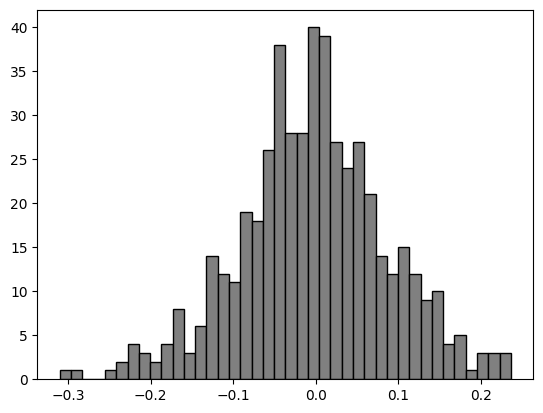

In [ ]:
cmb = u_model.trainable_variables[0][0]
plt.hist(cmb, edgecolor='black', bins=40, color='grey')

In [ ]:
# u_model.trainable_variables

In [ ]:
u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [ ]:
num_classes=2
u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                     factor=0.01,
                                     patience=10,
                                     min_lr=0.0001,
                                     cooldown=0)
history = u_model.fit(train_x, train_y,
                      batch_size=2,
                      epochs=150,
                      verbose=0)
y_val_pred_probs = u_model.predict(test_x, verbose=0)
thresholds = [0.5] * num_classes  # You can adjust these thresholds based on your requirements
y_val_pred_binary = np.zeros_like(y_val_pred_probs, dtype=int)
for i in range(num_classes):
  y_val_pred_binary[:, i] = (y_val_pred_probs[:, i] > thresholds[i]).astype(int)
y_val_pred_labels = l_encode.inverse_transform(np.argmax(y_val_pred_binary, axis=1))
y_true = l_encode.inverse_transform(np.argmax(test_y, axis=1))
scores = u_model.evaluate(train_x, train_y, verbose=0)
print("Loss Train: ", scores[0])
print("AKurasi Train: ", scores[1])
print("Akurasi Test : ", accuracy_score(y_true, y_val_pred_labels))
print("Precision Test : ", precision_score(y_true, y_val_pred_labels,average="macro"))
print("Recall Test : ", recall_score(y_true, y_val_pred_labels,average="macro"))
print("F1-Score Test : ", f1_score(y_true, y_val_pred_labels,average="macro"))

Loss Train:  3.4321763564548746e-07
AKurasi Train:  1.0
Akurasi Test :  0.9370629370629371
Precision Test :  0.9367253098760495
Recall Test :  0.9349860613301473
F1-Score Test :  0.9358072721831512


In [ ]:
history = u_model.fit(train_x, train_y, epochs=250, batch_size=3)

Epoch 1/250
167/167 [==============================] - 1s 2ms/step - loss: 1.3175 - accuracy: 0.4950
Epoch 2/250
167/167 [==============================] - 0s 2ms/step - loss: 0.7006 - accuracy: 0.6453
Epoch 3/250
167/167 [==============================] - 0s 2ms/step - loss: 0.6402 - accuracy: 0.6754
Epoch 4/250
167/167 [==============================] - 0s 2ms/step - loss: 0.6163 - accuracy: 0.6974
Epoch 5/250
167/167 [==============================] - 0s 2ms/step - loss: 0.5930 - accuracy: 0.7074
Epoch 6/250
167/167 [==============================] - 0s 2ms/step - loss: 0.5850 - accuracy: 0.6934
Epoch 7/250
167/167 [==============================] - 0s 2ms/step - loss: 0.5730 - accuracy: 0.7014
Epoch 8/250
167/167 [==============================] - 0s 2ms/step - loss: 0.5760 - accuracy: 0.6834
Epoch 9/250
167/167 [==============================] - 0s 2ms/step - loss: 0.5636 - accuracy: 0.6894
Epoch 10/250
167/167 [==============================] - 0s 3ms/step - loss: 0.5594 - accura

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, min_lr=0.00001, cooldown=0)
u_model.fit(train_x, train_y, batch_size=4, epochs=300,
          verbose=1, validation_data=(test_x, test_y), callbacks=[reduce_lr])
score = u_model.evaluate(test_x, test_y, verbose=0)
print('Test score:', score[0])
print('Test accuracy:', score[1])

Epoch 1/300
125/125 [==============================] - 1s 5ms/step - loss: 0.2558 - accuracy: 0.8958 - val_loss: 1.0319 - val_accuracy: 0.6916 - lr: 0.0010
Epoch 2/300
125/125 [==============================] - 1s 4ms/step - loss: 0.2585 - accuracy: 0.8778 - val_loss: 1.0003 - val_accuracy: 0.6963 - lr: 0.0010
Epoch 3/300
125/125 [==============================] - 1s 5ms/step - loss: 0.2762 - accuracy: 0.8617 - val_loss: 0.9226 - val_accuracy: 0.7056 - lr: 0.0010
Epoch 4/300
125/125 [==============================] - 1s 5ms/step - loss: 0.2545 - accuracy: 0.8737 - val_loss: 0.9569 - val_accuracy: 0.6822 - lr: 0.0010
Epoch 5/300
125/125 [==============================] - 1s 7ms/step - loss: 0.2525 - accuracy: 0.8978 - val_loss: 0.9943 - val_accuracy: 0.7056 - lr: 0.0010
Epoch 6/300
125/125 [==============================] - 1s 5ms/step - loss: 0.2673 - accuracy: 0.8737 - val_loss: 0.9454 - val_accuracy: 0.7103 - lr: 0.0010
Epoch 7/300
125/125 [==============================] - 1s 7ms/st

In [ ]:
scores = u_model.evaluate(test_x, test_y, verbose=0)

In [ ]:
scores

[0.8825234174728394, 0.7383177280426025]

In [ ]:
scores = u_model.evaluate(train_x, train_y, verbose=0)

In [ ]:
scores

[0.15699689090251923, 0.9238476753234863]

In [ ]:
      inputs=X
      targets=Y
      # Definisikan K-fold Cross Validator
      kfold = KFold(n_splits=3, shuffle=True)
      # Evaluasi model K-fold Cross Validation
      train_acc_per_fold = []
      train_loss_per_fold = []
      test_acc_per_fold = []
      test_loss_per_fold = []
      num_classes=2
      fold_no = 1
      for train, test in kfold.split(inputs, targets):
        u_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
        reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                      factor=0.01,
                                      patience=10,
                                      min_lr=0.0001,
                                      cooldown=0)
        history = u_model.fit(inputs[train], targets[train],
                              batch_size=4,
                              epochs=100,
                              verbose=1)

Epoch 1/100
119/119 [==============================] - 1s 2ms/step - loss: 0.6928 - accuracy: 0.5621
Epoch 2/100
119/119 [==============================] - 0s 2ms/step - loss: 0.6537 - accuracy: 0.6421
Epoch 3/100
119/119 [==============================] - 0s 2ms/step - loss: 0.6442 - accuracy: 0.6421
Epoch 4/100
119/119 [==============================] - 0s 2ms/step - loss: 0.6328 - accuracy: 0.6421
Epoch 5/100
119/119 [==============================] - 0s 2ms/step - loss: 0.6169 - accuracy: 0.6400
Epoch 6/100
119/119 [==============================] - 0s 2ms/step - loss: 0.5965 - accuracy: 0.6695
Epoch 7/100
119/119 [==============================] - 0s 2ms/step - loss: 0.5824 - accuracy: 0.6779
Epoch 8/100
119/119 [==============================] - 0s 2ms/step - loss: 0.5686 - accuracy: 0.6884
Epoch 9/100
119/119 [==============================] - 0s 2ms/step - loss: 0.5612 - accuracy: 0.6968
Epoch 10/100
119/119 [==============================] - 0s 2ms/step - loss: 0.5638 - accura

In [ ]:
scores = u_model.evaluate(test_x, test_y, verbose=0)
scores

[0.3234196603298187, 0.9018691778182983]

In [ ]:
a = [1,2,3,4,5,6,7,8,9]
random